# Simulating maximum Social Security benefit amounts
To use this notebook, you must create and set as the kernel the conda environment `ss-maxben-dev`.

In [20]:
# Import packages
import numpy as np
import pandas as pd
import pickle
import datetime as dt
import os
import matplotlib.pyplot as plt
from ogcore import output_plots as op

from bokeh.io import output_file, output_notebook
from bokeh.plotting import figure, show
from bokeh.models import (ColumnDataSource, Title, Legend, HoverTool,
                          NumeralTickFormatter)
from bokeh.models.annotations import Label, LabelSet
from bokeh.models.tickers import SingleIntervalTicker
from bokeh.core.property.numeric import Interval
from bokeh.palettes import Reds

In [21]:
# Set paths to work across Mac/Windows/Linux platforms
# Update cur_path to the path of the repsitory on your local machine
cur_path = "/Users/richardevans/Docs/Economics/OSE/Federal/CRFB2025/SS_MaxBen"
data_dir = os.path.join(cur_path, 'data')
cbodata_path = os.path.join(data_dir, 'cbo_debt_forecasts.csv')
images_dir = os.path.join(cur_path, 'images')
# Directories to save data
json_dir = os.path.join(cur_path, "json")
base_dir = os.path.join(cur_path, "code", "OUTPUT_BASELINE")
# reform_dir_G = os.path.join(cur_path, "OUTPUT_REFORM_G")
# reform_dir_Gr = os.path.join(cur_path, "OUTPUT_REFORM_Gr")
# reform_dir_regref = os.path.join(cur_path, "OUTPUT_REFORM_RegRef")


## 1. Run baseline simulation

### 1.1. Test debt/GDP path

In [22]:
p_base_path = os.path.join(base_dir, "model_params.pkl")
p_base = pickle.load(open(p_base_path, "rb"))
print(p_base.keys())

dict_keys(['frisch', 'g_y_annual', 'S', 'J', 'T', 'M', 'I', 'lambdas', 'e', 'starting_age', 'ending_age', 'constant_demographics', 'beta_annual', 'sigma', 'alpha_c', 'gamma', 'gamma_g', 'epsilon', 'io_matrix', 'Z', 'delta_annual', 'delta_g_annual', 'ltilde', 'world_int_rate_annual', 'initial_foreign_debt_ratio', 'zeta_D', 'zeta_K', 'tG1', 'tG2', 'alpha_T', 'alpha_G', 'alpha_I', 'alpha_bs_T', 'alpha_bs_G', 'alpha_bs_I', 'rho_G', 'alpha_RM_1', 'alpha_RM_T', 'g_RM', 'debt_ratio_ss', 'initial_debt_ratio', 'initial_Kg_ratio', 'r_gov_scale', 'r_gov_shift', 'cit_rate', 'c_corp_share_of_assets', 'adjustment_factor_for_cit_receipts', 'inv_tax_credit', 'tau_c', 'delta_tau_annual', 'h_wealth', 'm_wealth', 'p_wealth', 'tau_bq', 'tau_payroll', 'chi_b', 'chi_n', 'ubi_growthadj', 'ubi_nom_017', 'ubi_nom_1864', 'ubi_nom_65p', 'ubi_nom_max', 'eta', 'eta_RM', 'zeta', 'use_zeta', 'constant_rates', 'zero_taxes', 'analytical_mtrs', 'age_specific', 'retirement_age', 'pension_system', 'tau_p', 'indR', 'k_ret

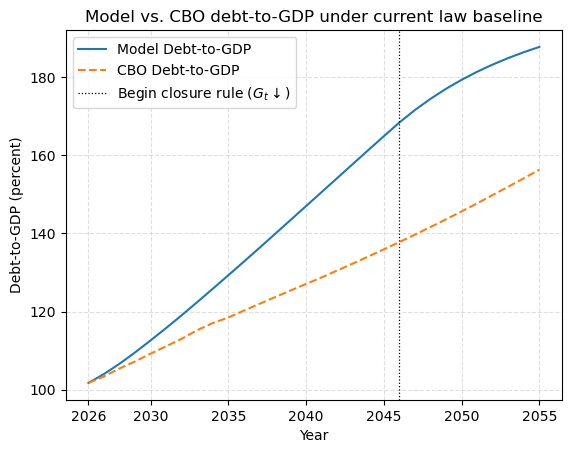

In [29]:
# Read in most recent CBO forecast of debt-to-GDP after enactment of OBBBA.
# Use CBO August 4, 2025 report "Effects on Deficits and the Debt of Public Law
# 119-21 and of Making Certain Tax Policies in the Act Permanent",
# https://www.cbo.gov/publication/61466, CBO July 21, 2025 report "Estimated
# Budgetary Effects of Public Law 119-21, to Provide for Reconciliation
# Pursuant to Title II of H. Con. Res. 14, Relative to CBO’s January 2025
# Baseline", https://www.cbo.gov/publication/61570, and CBO's March 2025 Long
# Term Budget Outlook,
cbo_file_path = os.path.join(data_dir, '51119-2025-03-LTBO-budget.xlsx')
cbo_debtGDP_mar2025 = pd.read_excel(
    cbo_file_path, sheet_name="1. Summary Ext Baseline",
    usecols="A:F, H:R, T:U, W", skiprows=9, nrows=31,
    names=[
        "fy_year", "indiv_inc_tax", "payroll_tax", "corp_inc_tax", "other_tax",
        "total_tax", "socsec_spnd", "medicare_spnd", "medicaid_etal_spnd",
        "other_mand_spnd", "discr_spend", "tot_nonint_spnd",
        "net_interest_spnd", "tot_spnd", "primary_deficit", "total_deficit",
        "fed_debt_held_by_pub", "medicare_offset_rcpts", "gdp",
        "gross_fed_debt"
    ]
)
# print(cbo_debtGDP_mar2025.describe())
# print(cbo_debtGDP_mar2025)
tpi_vars_base_path = os.path.join(base_dir, "TPI", "TPI_vars.pkl")
tpi_vars_base = pickle.load(open(tpi_vars_base_path, "rb"))
model_debtGDP_base = tpi_vars_base['D'] / tpi_vars_base['Y']
plt.plot(
    np.arange(2026, 2056), model_debtGDP_base[:30]*100,
    linestyle='-', label="Model Debt-to-GDP"
)
plt.plot(
    np.arange(2026,2056), cbo_debtGDP_mar2025['fed_debt_held_by_pub'][1:],
    linestyle='--', label="CBO Debt-to-GDP"
)
plt.axvline(
    x=p_base.start_year+p_base.tG1, linewidth=0.9, linestyle=":", color="k",
    label=r"Begin closure rule ($G_t\downarrow$)"
)
plt.title("Model vs. CBO debt-to-GDP under current law baseline")
plt.xlabel("Year")
plt.xticks([2026, 2030, 2035, 2040, 2045, 2050, 2055])
plt.grid(visible=True, which='major', axis='both', linestyle='--', alpha=0.4)
plt.ylabel("Debt-to-GDP (percent)")
plt.legend()
# fig_debtGDP_base = op.plot_gdp_ratio(
#     tpi_vars_base, p_base, start_year=p_base.start_year,
#     vertical_line_years=[p_base.start_year + p_base.tG1, 2055],
#     plot_title="Debt-to-GDP under current law baseline"
# )

In [19]:
cbo_debtGDP_mar2025['fed_debt_held_by_pub'][:2]

0     99.889
1    101.727
Name: fed_debt_held_by_pub, dtype: float64

In [6]:
tpi_vars_base.keys()

dict_keys(['Y', 'B', 'K', 'K_f', 'K_d', 'L', 'C', 'I', 'I_total', 'I_d', 'K_g', 'I_g', 'BQ', 'RM', 'Y_m', 'K_m', 'L_m', 'C_i', 'TR', 'agg_pension_outlays', 'G', 'UBI', 'total_tax_revenue', 'business_tax_revenue', 'iit_payroll_tax_revenue', 'iit_revenue', 'payroll_tax_revenue', 'bequest_tax_revenue', 'wealth_tax_revenue', 'cons_tax_revenue', 'D', 'D_f', 'D_d', 'new_borrowing', 'debt_service', 'new_borrowing_f', 'debt_service_f', 'r', 'r_gov', 'r_p', 'w', 'p_m', 'p_i', 'p_tilde', 'b_sp1', 'b_s', 'n', 'c', 'c_i', 'bq', 'rm', 'tr', 'ubi', 'before_tax_income', 'hh_taxes', 'etr', 'mtrx', 'mtry', 'euler_savings', 'euler_labor_leisure', 'resource_constraint_error'])